In [1]:
import numpy as np
from io import StringIO

# proliferating e-anyons, m-anyons subthreshold

data_str1 = """ 0.155875 0.230125 0.331500 0.422875 0.540625 0.638250 0.723375 0.802250
0.165875 0.234625 0.328750 0.435500 0.531875 0.640000 0.732875 0.791125
0.158750 0.236250 0.326125 0.443000 0.535250 0.629250 0.722750 0.793875
0.151125 0.226500 0.333875 0.432375 0.533250 0.640500 0.727125 0.796375
0.113125 0.188125 0.287250 0.407250 0.536875 0.646375 0.750250 0.832125
0.116125 0.195000 0.296875 0.413875 0.524875 0.654125 0.761500 0.835125
0.111375 0.190750 0.302375 0.412250 0.525875 0.655500 0.751875 0.833375
0.111750 0.188375 0.284875 0.415625 0.538875 0.652500 0.748500 0.829375
0.084750 0.160000 0.257875 0.404125 0.536750 0.664250 0.783125 0.860875
0.084250 0.158000 0.255500 0.401625 0.541375 0.661625 0.779875 0.864250
0.082500 0.153000 0.266750 0.384500 0.529375 0.659375 0.773375 0.865375
0.081250 0.165875 0.260375 0.391625 0.536625 0.672750 0.777125 0.861250
0.062875 0.124000 0.241250 0.379500 0.525625 0.677875 0.805875 0.888000
0.066750 0.132875 0.226875 0.374375 0.528625 0.687875 0.803500 0.885500
0.067375 0.140375 0.241500 0.385750 0.538500 0.693250 0.800000 0.890750
0.069250 0.130375 0.229500 0.373375 0.546250 0.683375 0.800000 0.883125 """
data_str2 = """ 0.158200 0.230300 0.327300 0.428900 0.539500 0.631700 0.728000 0.795800
0.159500 0.236900 0.319500 0.439700 0.529400 0.631500 0.724500 0.803100
0.154800 0.235400 0.328700 0.436900 0.531900 0.640800 0.720900 0.798900
0.159100 0.230500 0.320700 0.422000 0.532200 0.640000 0.727100 0.798600
0.108100 0.196100 0.290900 0.409200 0.544300 0.661000 0.744100 0.835600
0.115700 0.186000 0.295600 0.405200 0.531200 0.653500 0.758500 0.834900
0.115500 0.183700 0.300400 0.411100 0.533200 0.655000 0.755700 0.831600
0.115400 0.193300 0.291000 0.413000 0.525300 0.648700 0.748200 0.838600
0.079500 0.149600 0.258400 0.397400 0.534500 0.670100 0.776900 0.864100
0.080900 0.157500 0.264800 0.393800 0.544200 0.675300 0.780800 0.861700
0.086600 0.158000 0.265300 0.397100 0.542600 0.668400 0.787000 0.865500
0.089300 0.155500 0.275800 0.389100 0.532700 0.671900 0.783500 0.863200
0.063200 0.128200 0.239500 0.376000 0.527700 0.681100 0.801900 0.889300
0.069000 0.133900 0.234500 0.370200 0.543800 0.681400 0.810100 0.882300
0.063800 0.128100 0.237900 0.370900 0.543000 0.680100 0.812700 0.884800
0.060600 0.130900 0.238700 0.382100 0.528200 0.690800 0.799800 0.883300 """
data_str3 = """ 0.156100 0.230800 0.326000 0.434200 0.537900 0.644000 0.727300 0.795300
0.157900 0.230200 0.324900 0.423300 0.539800 0.637100 0.727200 0.804200
0.157700 0.224500 0.326400 0.434100 0.535400 0.645400 0.725600 0.804800
0.158100 0.231600 0.325900 0.432300 0.532300 0.644500 0.722500 0.804100
0.115600 0.197400 0.286300 0.403600 0.542200 0.653600 0.739800 0.834700
0.116300 0.188700 0.299300 0.405000 0.530100 0.645500 0.764800 0.835000
0.112000 0.191500 0.285800 0.405500 0.537200 0.653900 0.746700 0.829700
0.120600 0.191100 0.289300 0.410800 0.538900 0.653200 0.757400 0.837000
0.087000 0.156600 0.258500 0.398000 0.537200 0.671200 0.784300 0.863700
0.085800 0.154500 0.258700 0.398300 0.536400 0.668800 0.788400 0.870600
0.085200 0.157800 0.257000 0.394300 0.532000 0.662800 0.779500 0.861000
0.082400 0.157000 0.261000 0.403800 0.537600 0.668300 0.773100 0.856900
0.060600 0.134600 0.235200 0.379400 0.525300 0.681100 0.802900 0.888600
0.061700 0.132400 0.229100 0.380100 0.536200 0.684200 0.803900 0.894000
0.064600 0.130900 0.231400 0.371700 0.524300 0.684100 0.801100 0.889400
0.064100 0.132200 0.238300 0.385900 0.542300 0.681100 0.802000 0.886700 """
data_str4 = """ 0.159800 0.236500 0.325000 0.426500 0.538600 0.636800 0.727000 0.796800
0.149000 0.230500 0.330000 0.431400 0.538300 0.642100 0.725800 0.797200
0.154700 0.231200 0.327700 0.435700 0.535100 0.637100 0.726800 0.790200
0.158700 0.231000 0.318400 0.426100 0.538000 0.640400 0.723600 0.801300
0.113700 0.187900 0.296500 0.409900 0.537900 0.661100 0.759500 0.833000
0.119100 0.190300 0.291900 0.412700 0.537700 0.654100 0.755700 0.835000
0.115400 0.192800 0.290500 0.413800 0.528400 0.652300 0.761700 0.834300
0.112800 0.194200 0.289700 0.407700 0.525600 0.651100 0.749800 0.836600
0.087800 0.148800 0.264900 0.394200 0.537500 0.667000 0.784200 0.861500
0.083700 0.163700 0.260700 0.392100 0.528800 0.663700 0.777900 0.858400
0.084600 0.153900 0.256400 0.389900 0.530100 0.659300 0.781400 0.863300
0.082800 0.158600 0.260500 0.399300 0.531900 0.668900 0.776500 0.866800
0.058900 0.126900 0.244800 0.375700 0.540700 0.685600 0.799600 0.886000
0.062700 0.125600 0.236900 0.376700 0.542300 0.692100 0.799900 0.880600
0.063000 0.126700 0.238300 0.373300 0.537700 0.680100 0.808900 0.884400
0.065300 0.129700 0.230600 0.379700 0.541600 0.688000 0.802500 0.886100 """
data_str5 = """ 0.156500 0.240900 0.329000 0.433400 0.536200 0.634900 0.724200 0.797400
0.157100 0.237500 0.321300 0.422900 0.534100 0.636600 0.722000 0.795300
0.158100 0.231100 0.327200 0.436200 0.538700 0.634000 0.724200 0.795300
0.157100 0.224300 0.338900 0.433400 0.532400 0.634600 0.728300 0.798700
0.110700 0.190400 0.298500 0.420700 0.537300 0.656000 0.763400 0.829100
0.116900 0.191000 0.294200 0.411900 0.544400 0.663800 0.753000 0.834600
0.119100 0.192000 0.296100 0.409600 0.536700 0.658300 0.752300 0.830600
0.117400 0.190300 0.288900 0.415300 0.537600 0.652900 0.752700 0.832200
0.087100 0.159800 0.262000 0.399100 0.528300 0.667900 0.779700 0.858200
0.090000 0.165100 0.254200 0.387300 0.535600 0.668300 0.779900 0.867600
0.083300 0.156700 0.263900 0.396700 0.528000 0.663400 0.778900 0.859800
0.084500 0.159500 0.262200 0.391700 0.531000 0.678500 0.785700 0.860500
0.062700 0.125400 0.244000 0.379600 0.533400 0.690900 0.798000 0.887400
0.066600 0.131000 0.238700 0.385000 0.532700 0.680900 0.810400 0.889800
0.063700 0.131200 0.235900 0.372400 0.531800 0.675300 0.803500 0.883900
0.059800 0.122800 0.239600 0.366700 0.539000 0.688000 0.808500 0.883500 """
data_str6 = """ 0.150000 0.237400 0.334500 0.437400 0.540000 0.636200 0.727600 0.803800
0.154400 0.229000 0.323200 0.431700 0.545000 0.642000 0.732600 0.799200
0.161400 0.236200 0.322200 0.427900 0.535900 0.640800 0.729200 0.804400
0.161400 0.232800 0.335200 0.429500 0.535000 0.651200 0.727100 0.790600
0.114200 0.193100 0.283600 0.405900 0.540400 0.646100 0.749100 0.838400
0.120500 0.190900 0.294500 0.402400 0.532000 0.652100 0.756200 0.829800
0.120700 0.192300 0.298500 0.414300 0.539500 0.659600 0.752100 0.833800
0.112200 0.190500 0.293800 0.414300 0.529100 0.650300 0.748600 0.834600
0.085700 0.156900 0.251800 0.399000 0.524700 0.673300 0.782300 0.866200
0.084000 0.154700 0.255300 0.397700 0.527800 0.672800 0.781900 0.868100
0.081200 0.166000 0.261600 0.393000 0.533400 0.662600 0.781900 0.860900
0.079400 0.158400 0.263800 0.391000 0.529200 0.670700 0.783300 0.862400
0.061900 0.128500 0.239700 0.369200 0.527600 0.683400 0.797800 0.886400
0.061900 0.136100 0.243000 0.373200 0.537100 0.686700 0.811200 0.881100
0.068000 0.129300 0.232600 0.376600 0.539400 0.682700 0.800900 0.882500
0.058900 0.130800 0.232600 0.371400 0.535600 0.685200 0.797800 0.883800 """
data_str7 = """ 0.157800 0.234300 0.330100 0.435400 0.531200 0.635800 0.720200 0.802000
0.151700 0.239200 0.332100 0.439100 0.539700 0.634900 0.729800 0.799500
0.159400 0.231700 0.336000 0.429900 0.530700 0.635800 0.724400 0.798700
0.160600 0.236800 0.326300 0.425600 0.535900 0.648400 0.730300 0.798500
0.116800 0.193200 0.289900 0.414500 0.531100 0.656400 0.753100 0.832100
0.116400 0.194500 0.291900 0.414400 0.531500 0.656500 0.763500 0.830200
0.116500 0.193000 0.285500 0.407600 0.528300 0.653600 0.748300 0.838600
0.118200 0.186500 0.299900 0.410800 0.529100 0.651400 0.755500 0.832600
0.085600 0.158600 0.258000 0.403200 0.537800 0.672500 0.786000 0.862000
0.082100 0.161600 0.258400 0.394400 0.541900 0.664200 0.771100 0.855900
0.087600 0.158600 0.264800 0.402700 0.535100 0.668800 0.775300 0.862400
0.084400 0.154300 0.259100 0.388600 0.531700 0.671000 0.775300 0.861000
0.063000 0.133600 0.237600 0.376600 0.542100 0.685500 0.797000 0.883500
0.065100 0.132700 0.241500 0.376400 0.532900 0.684600 0.803500 0.885300
0.062500 0.133600 0.231600 0.383000 0.531700 0.678300 0.804000 0.884600
0.063200 0.128000 0.232300 0.375700 0.529000 0.684200 0.807800 0.886900 """
data_str8 = """ 0.150300 0.233700 0.320100 0.428300 0.533400 0.629200 0.731700 0.805100
0.157100 0.230600 0.333700 0.432400 0.540500 0.641200 0.729100 0.796800
0.158700 0.236300 0.321500 0.428600 0.537300 0.640200 0.722100 0.794900
0.157200 0.235600 0.325100 0.433800 0.543200 0.644800 0.724600 0.803400
0.111800 0.200200 0.292900 0.415000 0.538900 0.647700 0.753600 0.829600
0.112000 0.185000 0.293800 0.404100 0.524800 0.653600 0.749400 0.833800
0.117700 0.192900 0.296500 0.403000 0.542900 0.645800 0.746300 0.839200
0.112600 0.188600 0.285700 0.412100 0.528900 0.660100 0.752600 0.830500
0.080600 0.157800 0.266500 0.382500 0.539000 0.665900 0.785500 0.864800
0.082300 0.156100 0.249900 0.393400 0.532100 0.668700 0.781900 0.860800
0.086100 0.156700 0.266600 0.393700 0.539600 0.666700 0.783900 0.861300
0.085200 0.151500 0.258400 0.393800 0.535700 0.676500 0.773800 0.863300
0.064500 0.122000 0.235500 0.371800 0.529000 0.686200 0.804100 0.888500
0.064800 0.126200 0.235700 0.384300 0.532500 0.679200 0.804700 0.886400
0.062000 0.130600 0.234600 0.377800 0.530400 0.685700 0.803900 0.882200
0.058100 0.129600 0.244900 0.376300 0.528600 0.683200 0.799100 0.885200 """
data_str9 = """ 0.152800 0.230100 0.328500 0.431700 0.528300 0.639600 0.725300 0.797300
0.164700 0.233700 0.328500 0.433500 0.530600 0.640400 0.721800 0.803300
0.159600 0.236600 0.332400 0.435500 0.543700 0.625900 0.729300 0.802800
0.159600 0.235200 0.326500 0.423300 0.532700 0.626000 0.726900 0.798200
0.114600 0.189100 0.286900 0.408200 0.534500 0.648600 0.758100 0.833600
0.120000 0.185500 0.300000 0.411400 0.537200 0.646400 0.755300 0.835200
0.119800 0.189900 0.297600 0.396600 0.528500 0.654900 0.759800 0.839400
0.120400 0.197300 0.292100 0.403000 0.538800 0.664800 0.754000 0.837300
0.083300 0.150000 0.255100 0.389300 0.533100 0.666700 0.782300 0.861400
0.087300 0.159200 0.255500 0.391700 0.523100 0.669500 0.772900 0.858700
0.080300 0.153900 0.261400 0.394300 0.537600 0.667700 0.782100 0.857000
0.083300 0.162800 0.262900 0.387700 0.540900 0.671800 0.777500 0.860500
0.062000 0.132000 0.238600 0.375200 0.538800 0.683300 0.799000 0.882000
0.062600 0.134100 0.237200 0.378000 0.530800 0.690300 0.806300 0.886000
0.062300 0.128200 0.233300 0.385900 0.528200 0.681800 0.804200 0.885200
0.064500 0.131400 0.235000 0.382200 0.540300 0.694000 0.799800 0.888900 """
data_str10= """ 0.156900 0.232900 0.331000 0.436300 0.536100 0.637000 0.727900 0.797400
0.157600 0.232900 0.332600 0.430600 0.540000 0.647800 0.727500 0.803600
0.161200 0.233100 0.322000 0.423600 0.532700 0.636400 0.721900 0.793400
0.157400 0.233100 0.332000 0.436600 0.544600 0.644800 0.715400 0.795200
0.115500 0.190400 0.280700 0.410200 0.539500 0.660400 0.754500 0.842900
0.109400 0.187000 0.296300 0.405100 0.535500 0.650100 0.753400 0.837500
0.112900 0.188400 0.293900 0.410000 0.530900 0.654500 0.756200 0.829900
0.117800 0.188800 0.293800 0.410700 0.533800 0.648800 0.754200 0.834600
0.087000 0.158800 0.260300 0.395100 0.551800 0.670000 0.780900 0.857800
0.084800 0.156500 0.264000 0.392400 0.534700 0.667400 0.781000 0.864600
0.083200 0.153800 0.256400 0.382900 0.529500 0.658200 0.774000 0.861000
0.087100 0.157700 0.262100 0.389300 0.531800 0.666500 0.773700 0.867600
0.062500 0.128900 0.238100 0.374100 0.542700 0.677600 0.809700 0.886200
0.061000 0.131600 0.230900 0.375400 0.542900 0.693400 0.799100 0.882900
0.062500 0.128900 0.227200 0.386600 0.535300 0.694500 0.807100 0.879500
0.060500 0.132500 0.232600 0.373800 0.535200 0.687600 0.801500 0.884200 """

run1 = np.loadtxt(StringIO(data_str1))
run2 = np.loadtxt(StringIO(data_str2))
run3 = np.loadtxt(StringIO(data_str3))
run4 = np.loadtxt(StringIO(data_str4))
run5 = np.loadtxt(StringIO(data_str5))
run6 = np.loadtxt(StringIO(data_str6))
run7 = np.loadtxt(StringIO(data_str7))
run8 = np.loadtxt(StringIO(data_str8))
run9 = np.loadtxt(StringIO(data_str9))
run10= np.loadtxt(StringIO(data_str10))

runs = np.stack([run1, run2, run3, run4, run5, run6, run7, run8, run9, run10]) #, run2, run3, run4, run5, run6, run7, run8, run9, run10

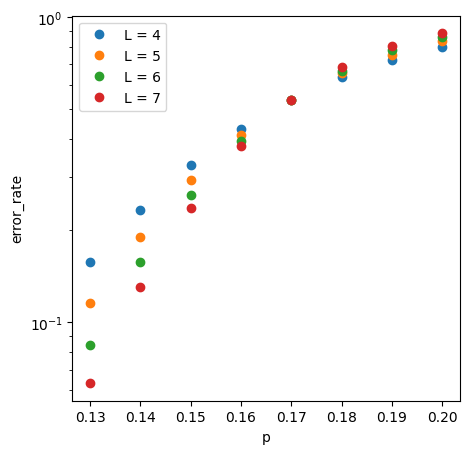

In [2]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

p = [0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2]
L = [4, 5, 6, 7]

error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

plt.figure(figsize=(5, 5))
for l in range(len(L)):
    plt.plot(p, error_rate[l], 'o', label=f'L = {L[l]}')
    
plt.yscale('log')
plt.xlabel('p')
plt.ylabel('error_rate')
plt.legend()
plt.show()

In [10]:
from scipy.optimize import curve_fit

p = np.tile(np.array( [0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2]), 4)
L = np.repeat(np.array([4,5,6,7]), 8)
rate = error_rate.flatten()
n = 10000
rate_error = np.array([])
for i in range(len(p)):
    se = (rate[i]*(1-rate[i])/n)**(1/2)
    rate_error = np.append(rate_error, se)

In [11]:
# Define the model
def model(pL, pc, nu, A, B, C):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [0.17120533 2.14103251 0.53386079 5.05028681 2.2788519 ]
Parameter standard deviations: [0.00073094 0.05785731 0.00804054 0.11413336 0.29893604]


np.float64(141.85719584756282)

In [12]:
# Define the model
def model(pL, pc, nu, A, B, C, D):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0], full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [  0.16962277   1.37752319   0.52850412   3.76639817  -1.77744043
 -45.53404747]
Parameter standard deviations: [5.35384374e-04 3.80996078e-02 6.79047262e-03 1.23185532e-01
 3.00773107e-01 4.37055956e+00]


np.float64(16.020910696913358)

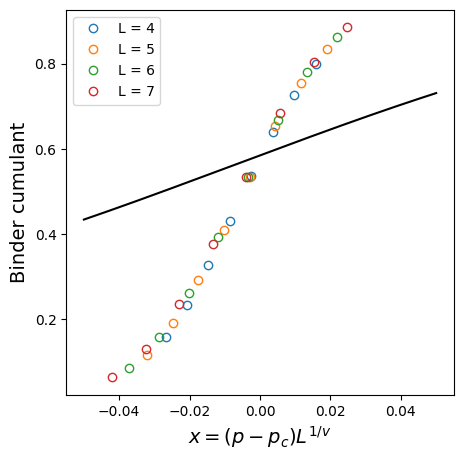

In [13]:
pc = 0.16580725
nu = 1.24516987
A = 0.58468523
B = 3.08067503
C = -0.91586378
D = -43.74616276

p = [0.157, 0.159, 0.161, 0.163, 0.165, 0.167, 0.169, 0.171]
L = [4, 5, 6, 7]
error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

x = np.zeros((len(L), len(p)))
plt.figure(figsize=(5, 5))
for l in range(len(L)):
    for i in range(len(p)):
        x[l][i] = (p[i]-pc) * (L[l]**(1/nu))
    plt.plot(x[l], error_rate[l], 'o', markerfacecolor='none', label=f'L = {L[l]}')
x_data = np.linspace(-0.05, 0.05, 1000)
y_data = A + B*x_data + C*(x_data**2) +D*(x_data**3)
plt.plot(x_data, y_data, color = 'k')

#ax = plt.gca()
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

#plt.yscale('log')
plt.xlabel('$x=(p-p_c)L^{1/v}$', fontsize=14)
plt.ylabel('Binder cumulant', fontsize=14)
plt.legend()
#plt.savefig('modified-D4.png', dpi=600, bbox_inches='tight')
plt.show()